In [1]:
using Gridap        
using GridapGmsh
using Gridap.Geometry
using Gridap.TensorValues
using Plots
using LinearAlgebra
using  Gridap.Fields
using  Gridap.CellData
using  Gridap.ReferenceFEs  
using  Gridap.Fields
using Gridap.FESpaces
using NearestNeighbors

In [2]:
using LinearAlgebra
using Distributions      
using Plots

In [3]:
model = GmshDiscreteModel("WedgeSPlitting.msh")
writevtk(model,"WedgeSPlitting")

Info    : Reading 'WedgeSPlitting.msh'...
Info    : 41 entities
Info    : 29229 nodes
Info    : 58241 elements
Info    : Done reading 'WedgeSPlitting.msh'


3-element Vector{Vector{String}}:
 ["WedgeSPlitting_0.vtu"]
 ["WedgeSPlitting_1.vtu"]
 ["WedgeSPlitting_2.vtu"]

In [4]:
const ν = 0.18
const E = 28300
const G = E/(2*(1+ν))

11991.525423728814

In [5]:
const λ = (E*ν)/((1+ν)*(1-2*ν))
const μ = G
const κ = λ + μ

18736.758474576272

In [6]:
D_x = 0.01
D_y = 0.01
G0_n = 1.25e-5
G0_s = 1.25e-5
τ = 1e-9
R = 0.01
Gc_n = 4.5
Gc_s = 12.75  
Fr_Ang = 0
tFr_Ang = tand(Fr_Ang)

0.0

In [7]:
θ = 0.0 
r_nbh = 0.01

0.01

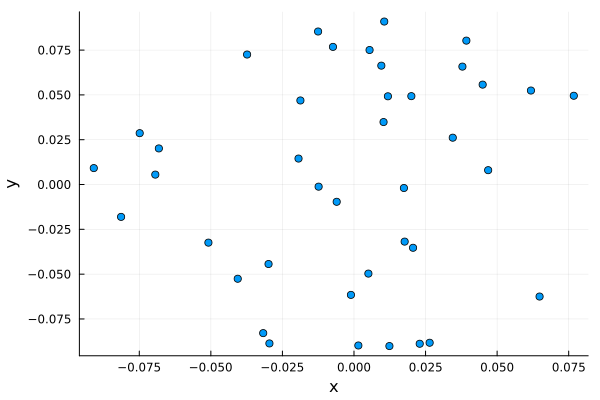

In [8]:
using LinearAlgebra
using Random
using Plots

function generate_elliptical_points(N::Int, a, b, θ)
    
    θr = deg2rad(θ)

    
    R = [cos(θr) -sin(θr); sin(θr) cos(θr)]

   
    r = sqrt.(rand(N))    
    φ = 2.0 .* π .* rand(N)     
    x = r .* cos.(φ)
    y = r .* sin.(φ)

    pts = [x'; y']         

    
    scale = Diagonal([a, b])
    ellipse_pts = R' * (scale * pts)
point_objs = [Point(ellipse_pts[1, i], ellipse_pts[2, i]) for i in 1:N]
    return point_objs, φ
end


N = 40
a = 0.1  
b = 0.1 
ellipse_pts,Bond_orient = generate_elliptical_points(N, a, b, 0.0)
origin_point = Point(0.0, 0.0)
cod_final = ellipse_pts

r_x = [val[1] for val in cod_final ]


r_y = [val[2] for val in cod_final ]   
N = length(cod_final)
Dir_Vec = ones(N)


μ_0_pdf = 0.0
r_discr = norm.(cod_final)

 C = [ (xi - xj)^2 for xi in r_discr, xj in r_discr ] 

ϵ = 0.5e-10

p0 = fill(1.0 / N, N)





x = [p[1] for p in cod_final]
y = [p[2] for p in cod_final]


scatter(x, y, legend=false,
        xlabel="x", ylabel="y")


In [9]:
r_discr

40-element Vector{Float64}:
 0.053218093113908474
 0.09005248194807663
 0.047552294671352094
 0.0408831618362295
 0.06158762727825999
 0.017551031378663488
 0.07590725474419484
 0.08877047947027839
 0.06031085077060929
 0.049954889051447536
 0.08157261467445856
 0.08106070486876266
 0.043280269651324754
 ⋮
 0.036443026307704504
 0.0504914529890026
 0.08333574587397961
 0.05346812114002996
 0.09344946613396314
 0.012412636476691623
 0.09154087624015268
 0.09136898801381056
 0.07524262596652487
 0.050626983821507224
 0.07159975386263132
 0.09097548047126787

In [10]:
σ(ε)= λ*tr(ε)*one(ε) + 2*μ*ε 

σ (generic function with 1 method)

In [11]:
degree = 2
Ω = Triangulation(model)
dΩ = Measure(Ω,degree)

Measure()

In [12]:
labels = get_face_labeling(model)

FaceLabeling:
 0-faces: 29229
 1-faces: 87457
 2-faces: 58229
 tags: 5
 entities: 41

In [13]:
Gr = get_grid(model)
nodes = get_node_coordinates(Gr)
Nₑ, Nₙ = num_cells(model), num_nodes(model)
nodeCoordX, nodeCoordY = [nodes[i][1] for i in 1:Nₙ], [nodes[i][2] for i in 1:Nₙ]
elem = get_cell_node_ids(Gr)

58229-element Gridap.Arrays.Table{Int32, Vector{Int32}, Vector{Int32}}:
 [508, 15969, 28736]
 [28258, 28281, 28455]
 [22553, 23144, 27068]
 [23150, 23582, 27609]
 [28804, 28806, 28827]
 [26378, 26387, 28731]
 [27384, 27385, 28971]
 [17550, 18769, 27694]
 [15138, 22536, 22543]
 [28644, 28656, 28659]
 [508, 28735, 28736]
 [17262, 28524, 28888]
 [15045, 27274, 28596]
 ⋮
 [29090, 29093, 29094]
 [29090, 29094, 29100]
 [29093, 29096, 29097]
 [29198, 29199, 29200]
 [29199, 29200, 29201]
 [29208, 29209, 29211]
 [29208, 29211, 29212]
 [29208, 29213, 29222]
 [29211, 29212, 29228]
 [29214, 29215, 29216]
 [29214, 29216, 29217]
 [29214, 29221, 29229]

In [14]:
using NearestNeighbors
data = zeros(2,Nₙ)
data[1,:] =nodeCoordX
data[2,:] =nodeCoordY
points = data
balltree = BallTree(data)
idxs = inrange(balltree, points, r_nbh, true)

29229-element Vector{Vector{Int64}}:
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]
 [10]
 [11]
 [12]
 [13]
 ⋮
 [29218]
 [29219]
 [29220]
 [29221]
 [29222]
 [29223]
 [29224]
 [29225]
 [29226]
 [29227]
 [29228]
 [29229]

In [15]:
function G_kill(σ_eq_x_n, G0_eq)
G_kill_x = 0.5 .* G0_eq .* ((σ_eq_x_n  .- 1) .+ abs.(σ_eq_x_n  .- 1)  ) .* σ_eq_x_n ./ T
    return G_kill_x
end 

G_kill (generic function with 1 method)

In [16]:
function new_EnergyState(ψPlusPrev_in,ψhPos_in)
    ψPlus_in = ψhPos_in
    if ψPlus_in <= ψPlusPrev_in
        ψPlus_out = ψPlusPrev_in 
        damaged = false
    else
        ψPlus_out = ψPlus_in
        damaged = true
    end
    damaged, ψPlus_out   
end

new_EnergyState (generic function with 1 method)

In [17]:
exp.(-Float64.(C) ./ ϵ)

40×40 Matrix{Float64}:
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0           0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  …  0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0           0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0 

In [18]:

maxiter = 1
sinkhorn_iters = 1
tol = 1e-9
function sinkhorn_JKO_step(p_k_x, C, ϵ, τ, V_x, sinkhorn_iters, tol)

    N = length(p_k_x)
    p_k_x = Float64.(p_k_x)
   
    K =  exp.(-Float64.(C) ./ ϵ) 
    p_next_x = copy(p_k_x)
    q_x = copy(p_k_x)

    for t in 1:maxiter
        
        q_x = exp.(-2*(τ/ϵ) .* (2 ./ r_discr) .* V_x  .* D_x)

     
        p_tilde_x = p_k_x .* q_x

     
        u_x = ones(N)
        v_x = ones(N)
      
        small = 1e-16
        for _ in 1:sinkhorn_iters
            u_x = p_k_x ./ (K * v_x .+ small)
            v_x = p_tilde_x ./ (K' * u_x .+ small)

        end

        Π_x = Diagonal(u_x) * K * Diagonal(v_x)
        p_new_x = vec(sum(Π_x, dims=1))


        p_next_x = p_new_x

    end
    bar_w_nds_x = sum(p_next_x .* exp.(dot.(-cod_final, cod_final)))

    return bar_w_nds_x  ,  p_next_x
end

sinkhorn_JKO_step (generic function with 1 method)

In [19]:
function nonLocal_w_bar_fe(ε_field, p_0_nds_x,Gk_history_old) 
  
    ε_vals = evaluate(ε_field, x_S) 
    
    caches_x = [array_cache(ε_vals) for _ in 1:Threads.nthreads()]

  
    T_type = eltype(ε_vals[1]) 
    
    
    Gk_sum_x = zeros(T_type, Nₙ)
    Gk_count_x = zeros(Int, Nₙ)
    
    
    
    for iel in 1:Nₑ 
        cache_x = caches_x[Threads.threadid()]
        ElNdInd = elem[iel]
        
      
        val_ε_tensor = getindex!(cache_x, ε_vals, iel)
        
        
        tensor_ip = (sum(val_ε_tensor))/(length(val_ε_tensor)) 
        
        for node in ElNdInd
            Gk_sum_x[node] += tensor_ip
            Gk_count_x[node] += 1
        end
    end
    
    # Average to get nodal Tensors
    Gk_nds_x = Gk_sum_x ./ Gk_count_x
    
#    Gk_nds_NL = zeros(T_type, Nₙ)
#     Threads.@threads for nd_id in 1:Nₙ
#         NeighHood = idxs[nd_id]
#         @inbounds Gk_nds_NL[nd_id] = (sum(Gk_nds_x[NeighHood]) ) / (length(NeighHood))
#     end
    

    # === Stage 3: Compute w_bar and new p ===
    w_bar_nds_x = zeros(Nₙ)
    p_new_x = zeros(N, Nₙ) 
    
    Gk_history_new = zeros(N, Nₙ)
    
    Threads.@threads for nd_id in 1:Nₙ
        # 1. Retrieve the aggregated Tensor for this node
        G_tensor_nd = Gk_nds_x[nd_id]
        
        # 2. Project Tensor onto the 5 directions to get a Vector of Scalars
        # Logic: Scalar_i = r_i ⋅ (Tensor ⋅ r_i) 
        # Note: We map over the list of vectors in r_x
        Gk_nd_Aniso_x1_temp = map(r -> dot(r, G_tensor_nd ⋅ r), cod_final ./ norm.(cod_final))
        
          Gk_nd_Aniso_x2_temp = map(n -> begin
    n_perp = VectorValue(-n[2], n[1]) 
    dot(n_perp, G_tensor_nd ⋅ n_perp)
            end, cod_final ./ norm.(cod_final)) 
        
        Gk_nd_Aniso_rn_temp = map(r -> begin
 n_perp = VectorValue(-r[2], r[1]) 
    dot(r, G_tensor_nd ⋅ n_perp) + dot(n_perp, G_tensor_nd ⋅ r)
end, cod_final ./ norm.(cod_final))
        
        Gk_nd_Aniso_x2 = Gk_nd_Aniso_x2_temp
        Gk_nd_Aniso_x1 = Gk_nd_Aniso_x1_temp 
        
        Gk_nd_Aniso_x1_nor = max.(Gk_nd_Aniso_x2_temp,Gk_nd_Aniso_x1_temp,0.0)
        Gk_nd_Aniso_x1_shear = 0.5 .* Gk_nd_Aniso_rn_temp
        Gk_nd_Aniso_x1_comp = min.(Gk_nd_Aniso_x2_temp + Gk_nd_Aniso_x1_temp,0.0)
        Gk_nd_Aniso_x1_cs = min.(Gk_nd_Aniso_rn_temp,0.0)
        
        Gk_nd_Eq = sqrt.( Gk_nd_Aniso_x1_nor .^2 ./ Gc_n.^2 +  Gk_nd_Aniso_x1_shear.^2 ./((Gc_s .- Gk_nd_Aniso_x1_nor .* tFr_Ang .* sign.(Gk_nd_Aniso_x1_shear) ).^2))
        mod_mix =  atan.(( max.(Gk_nd_Aniso_x2_temp, Gk_nd_Aniso_x1_temp) ) ./ abs.( ( (Gk_nd_Aniso_x1_shear)  ) .+ 1e-8) )
        #Gc_eq = sqrt.( (Gc_n.^2 .* (Gc_s .+ Gk_nd_Aniso_x2 .* tFr_Ang).^2) ./ (Gc_n.^2 .* (cos.(mod_mix)).^2 .+ (Gc_s .+ Gk_nd_Aniso_x2 .* tFr_Ang).^2 .* (sin.(mod_mix)).^2  ))
         G0_eq = sqrt.( (G0_n.^2 * G0_s.^2) ./ (G0_n.^2 .* (cos.(mod_mix)).^2 .+ G0_s.^2 .* (sin.(mod_mix)).^2  ))
        Gk_nd_Aniso = G_kill(Gk_nd_Eq , G0_eq)
        
        Gk_old_local = Gk_history_old[:, nd_id]
        Gk_max_local = max.(Gk_nd_Aniso, Gk_old_local)
        Gk_history_new[:, nd_id] .= Gk_max_local
        p_0_in_x = p_0_nds_x[:, nd_id]
        
        @inbounds w_bar_nds_x[nd_id], p_temp_x = sinkhorn_JKO_step(
            p_0_in_x, C, ϵ, τ,  Gk_max_local, sinkhorn_iters, tol
        )
        p_new_x[:, nd_id] .= p_temp_x
    end

    return FEFunction(Vphi, w_bar_nds_x .+ 1e-6), p_new_x, Gk_history_new 
end

nonLocal_w_bar_fe (generic function with 1 method)

In [20]:
LoadTagId = get_tag_from_name(labels,"RightEdge")
Γ_Load = BoundaryTriangulation(model,tags = LoadTagId)
dΓ_Load = Measure(Γ_Load,degree)
n_Γ_Load = get_normal_vector(Γ_Load)

LoadTagId2 = get_tag_from_name(labels,"LeftEdge")
Γ_Load2 = BoundaryTriangulation(model,tags = LoadTagId2)
dΓ_Load2 = Measure(Γ_Load2,degree)
n_Γ_Load2 = get_normal_vector(Γ_Load2)


GenericCellField():
 num_cells: 3
 DomainStyle: ReferenceDomain()
 Triangulation: BoundaryTriangulation()
 Triangulation id: 15501450950934323474

In [21]:
reffe_Disp = ReferenceFE(lagrangian,VectorValue{2,Float64},1)
V0_Disp = TestFESpace(model,reffe_Disp;
          conformity=:H1,
          dirichlet_tags=["LeftSupport","RightSupport","LeftEdge","RightEdge"],
          dirichlet_masks=[(false,true),(false,true),(true,false),(true,false)])

UnconstrainedFESpace()

In [22]:
reffephi  = ReferenceFE(lagrangian,Float64,1)
Vphi  = TestFESpace(model,reffephi;
          conformity=:H1)

UnconstrainedFESpace()

In [23]:
function step_disp(uApp,uh,p_0_nds_x,ϕ,Gk_history_new)
uApp1(x) = VectorValue(0.0,0.0)
uApp2(x) = VectorValue(0.0,0.0)
uApp3(x) = VectorValue(-uApp,0.0)
uApp4(x) = VectorValue(uApp,0.0)
U_Disp = TrialFESpace(V0_Disp,[uApp1,uApp2,uApp3,uApp4])
 ϕ,p_0_nds_x,Gk_history_new  = nonLocal_w_bar_fe(σ∘((ε(uh))) ,p_0_nds_x,Gk_history_new)
a(u,v) = ∫( ε(v) ⊙ ((σ∘((ε(u))))  .*(ϕ+1e-6)))dΩ
l(v) = 0.0 
op = AffineFEOperator(a,l,U_Disp,V0_Disp)
ls = LUSolver()
solver = LinearFESolver(ls)
uh = solve(solver,op)
    return uh, ϕ, p_0_nds_x, Gk_history_new 
end

step_disp (generic function with 1 method)

In [24]:
function project(q,model,dΩ,order)
  reffe = ReferenceFE(lagrangian,Float64,order)
  V = FESpace(model,reffe,conformity=:L2)
  a(u,v) = ∫( u*v )*dΩ
  l(v) = ∫( v*q )*dΩ
  op = AffineFEOperator(a,l,V,V)
  qh = solve(op)
  qh
end

project (generic function with 1 method)

In [25]:
dΩ_ro = Measure(Ω,1)
x_S = get_cell_points(dΩ_ro)

CellPoint()

In [26]:
cd("SinkhornResults")
cd("WedgeSplitting")
cd("msh1p25")

In [27]:
uh = zero(V0_Disp)
Tmax = 0.36
delT = 3.0e-4
vApp = 1.0
count_n = 0
T = 0.0
Load = Float64[]
Displacement = Float64[]
push!(Load, 0.0)
push!(Displacement, 0.0)
Gk_history_new = zeros(N, Nₙ)
uh_prev = zero(V0_Disp)
uh_in_FE = uh
f_new = 1.0
ϕ_prev = interpolate_everywhere(f_new,Vphi)
ϕ = interpolate_everywhere(f_new,Vphi)
ϕ_x = interpolate_everywhere(f_new,Vphi)
ϕ_y = interpolate_everywhere(f_new,Vphi)
innerMax = 5
G_k_cell_x = CellState(0.0,dΩ_ro)
G_k_cell_y = CellState(0.0,dΩ_ro)
p0_nds_x = p0 .* ones(1, Nₙ)
p0_nds_y = p0 .* ones(1, Nₙ)
start_time = time()
while T <= Tmax
    count_n = count_n + 1

T = T + delT
uApp  = T*vApp
    print("\n Entering displacemtent step :", float(uApp))
 for inner = 1:innerMax
uh,ϕ,p0_nds_x,Gk_history_new =  step_disp(uApp,uh,p0_nds_x,ϕ,Gk_history_new)
e = uh - uh_in_FE

err = sqrt(sum( ∫( e⊙e )*dΩ ))
ϕ_prev = ϕ
uh_in_FE = uh
print("\n error = ",float(err))
        if err < 1e-8
            break 
        end  
    end
Node_Force = sum(∫( n_Γ_Load ⋅ (σ∘( (ε(uh))) ).*ϕ)dΓ_Load)
push!(Load, abs(Node_Force[1]))
push!(Displacement, 2*uApp)


if mod(count_n,10) == 0
writevtk(Ω,"results_NonLocal_$count_n",cellfields=["disp"=>uh,"phi"=>ϕ ])   
    end
    
    end
end_time = time()
elapsed_time = end_time - start_time


 Entering displacemtent step :0.0003
 error = 0.11064691150676234
 error = 2.7346490560965716e-15
 Entering displacemtent step :0.0006
 error = 0.11064691150676104
 error = 2.541042291413787e-14
 Entering displacemtent step :0.0009
 error = 0.11064691150676534
 error = 1.6770267609964168e-14
 Entering displacemtent step :0.0012
 error = 0.11064691150675254
 error = 3.123288963840541e-14
 Entering displacemtent step :0.0014999999999999998
 error = 0.11064691150676476
 error = 6.195925935612566e-14
 Entering displacemtent step :0.0017999999999999997
 error = 0.11064691150677525
 error = 2.871599409739765e-13
 Entering displacemtent step :0.0021
 error = 0.1106469115067693
 error = 3.38725652991446e-13
 Entering displacemtent step :0.0024
 error = 0.1106469115067772
 error = 2.6374867792027134e-13
 Entering displacemtent step :0.0026999999999999997
 error = 0.11064691150677805
 error = 7.168082145931753e-14
 Entering displacemtent step :0.0029999999999999996
 error = 0.11064691150677264


 Entering displacemtent step :0.026100000000000054
 error = 0.11064851224314805
 error = 2.3716243817066835e-6
 error = 2.3732753826395976e-6
 error = 2.3749313119681435e-6
 error = 2.376593957250154e-6
 Entering displacemtent step :0.026400000000000055
 error = 0.11064886724381073
 error = 2.8063271683286352e-6
 error = 2.808182130081053e-6
 error = 2.8100467077255315e-6
 error = 2.8119081927198833e-6
 Entering displacemtent step :0.026700000000000057
 error = 0.11064926220305661
 error = 3.2681918723951795e-6
 error = 3.270569320636388e-6
 error = 3.272946781431391e-6
 error = 3.2753308948699865e-6
 Entering displacemtent step :0.02700000000000006
 error = 0.11064970755951038
 error = 3.7796039201024063e-6
 error = 3.7821211014962753e-6
 error = 3.7846399113306535e-6
 error = 3.787157948005098e-6
 Entering displacemtent step :0.02730000000000006
 error = 0.1106501950026593
 error = 4.3101509367803085e-6
 error = 4.312853178302301e-6
 error = 4.315554925634544e-6
 error = 4.3182562139

 error = 0.1107545037623936
 error = 9.505987794813311e-5
 error = 9.536137702624121e-5
 error = 9.566504408905305e-5
 error = 9.597069004877666e-5
 Entering displacemtent step :0.04170000000000014
 error = 0.11075994940136076
 error = 9.96856542793054e-5
 error = 0.00010001030518949671
 error = 0.00010033710430669489
 error = 0.00010066616125470809
 Entering displacemtent step :0.04200000000000014
 error = 0.11076562376844484
 error = 0.00010450908910926987
 error = 0.00010486000592924303
 error = 0.00010521336250919878
 error = 0.00010556943204890294
 Entering displacemtent step :0.04230000000000014
 error = 0.11077154512965781
 error = 0.00010954984313792039
 error = 0.00010992854285356404
 error = 0.00011030977600272176
 error = 0.00011069369778827991
 Entering displacemtent step :0.042600000000000145
 error = 0.11077772142387274
 error = 0.00011481234734625804
 error = 0.0001152206599770194
 error = 0.00011563191790704335
 error = 0.00011604599015431507
 Entering displacemtent ste

 error = 0.0007297194633215303
 error = 0.000727231325615916
 error = 0.00072465110961619
 error = 0.0007219875637370717
 Entering displacemtent step :0.05670000000000022
 error = 0.11147965090828363
 error = 0.0007264699713344469
 error = 0.0007236046318898679
 error = 0.0007206965560930094
 error = 0.0007177574710262473
 Entering displacemtent step :0.057000000000000224
 error = 0.11148963667187797
 error = 0.0007217705443626701
 error = 0.0007187911050802004
 error = 0.000715830709009265
 error = 0.0007129020925038084
 Entering displacemtent step :0.057300000000000226
 error = 0.1115000925400873
 error = 0.0007170384477770671
 error = 0.0007142765384437109
 error = 0.0007116157213292908
 error = 0.000709047793530867
 Entering displacemtent step :0.05760000000000023
 error = 0.11151157095968868
 error = 0.000714010542676717
 error = 0.0007117891858029441
 error = 0.0007097068129036665
 error = 0.0007077703497491143
 Entering displacemtent step :0.05790000000000023
 error = 0.11152454

 Entering displacemtent step :0.0717000000000001
 error = 0.11262541175183544
 error = 0.001406177672951658
 error = 0.0014032490508680852
 error = 0.0014005968755997696
 error = 0.001398250797288224
 Entering displacemtent step :0.07200000000000009
 error = 0.11264731140568719
 error = 0.001409268961349267
 error = 0.0014080575789570287
 error = 0.0014072447076561142
 error = 0.0014068463881489958
 Entering displacemtent step :0.07230000000000009
 error = 0.11267207211968015
 error = 0.0014220095779161183
 error = 0.0014230807437369032
 error = 0.0014245912528324017
 error = 0.0014265569607725614
 Entering displacemtent step :0.07260000000000008
 error = 0.11270041784406369
 error = 0.0014464490261019516
 error = 0.0014498048418006512
 error = 0.0014534804898636644
 error = 0.0014574379759674174
 Entering displacemtent step :0.07290000000000008
 error = 0.1127320962572773
 error = 0.0014809469445505603
 error = 0.0014856309746369846
 error = 0.0014904309568725647
 error = 0.0014952820

...

 error = 0.008391152222172123
 error = 0.008386489503183296
 error = 0.008382191173627956
 Entering displacemtent step :0.30480000000000107
 error = 0.14582082450269138
 error = 0.008393132629945777
 error = 0.00839068866980112
 error = 0.008387582903661605
 error = 0.008383415450452573
 Entering displacemtent step :0.3051000000000011
 error = 0.14583086622654604
 error = 0.008386755809847168
 error = 0.008376719547917192
 error = 0.008364381747042723
 error = 0.008350015503295598
 Entering displacemtent step :0.3054000000000011
 error = 0.14583070820762475
 error = 0.008334299115837142
 error = 0.008317804901319182
 error = 0.008302268412377923
 error = 0.008288447427980192
 Entering displacemtent step :0.30570000000000114
 error = 0.14582900709313548
 error = 0.008283856085021642
 error = 0.008276964734359245
 error = 0.008272859339699346
 error = 0.008271193323994327
 Entering displacemtent step :0.30600000000000116
 error = 0.14584575205528644
 error = 0.008291226037915236
 error =

 error = 0.0077375560918105015
 error = 0.007727027078794677
 error = 0.007716993629209695
 error = 0.0077081179694632835
 Entering displacemtent step :0.32040000000000224
 error = 0.14632891023584668
 error = 0.007710966620433197
 error = 0.0077078427976443676
 error = 0.007706317403689756
 error = 0.007706055052245436
 Entering displacemtent step :0.32070000000000226
 error = 0.14635166559524074
 error = 0.0077216984734150215
 error = 0.007722181080277942
 error = 0.007722681161988895
 error = 0.007723432379720984
 Entering displacemtent step :0.3210000000000023
 error = 0.14637033440956174
 error = 0.007742105412372181
 error = 0.0077460265581081635
 error = 0.007751332131690741
 error = 0.007758086875394777
 Entering displacemtent step :0.3213000000000023
 error = 0.14638332478352134
 error = 0.007790631252292526
 error = 0.0078008271339432755
 error = 0.00781137920045667
 error = 0.007821683911029177
 Entering displacemtent step :0.32160000000000233
 error = 0.14639497465772633
 e

 Entering displacemtent step :0.3357000000000034
 error = 0.1467916127966641
 error = 0.007232424545430637
 error = 0.007236199219321463
 error = 0.00724086085046262
 error = 0.007245276029676867
 Entering displacemtent step :0.3360000000000034
 error = 0.14679830030159957
 error = 0.007258000127693384
 error = 0.0072469308339356605
 error = 0.007226424775840699
 error = 0.007198164311827893
 Entering displacemtent step :0.33630000000000343
 error = 0.14679564871715728
 error = 0.007153031792624214
 error = 0.007132065849631937
 error = 0.007117532803394626
 error = 0.00710772402004128
 Entering displacemtent step :0.33660000000000345
 error = 0.14679537812686
 error = 0.0071085041592962115
 error = 0.0071045328802474515
 error = 0.007101140923775982
 error = 0.007098763670149811
 Entering displacemtent step :0.3369000000000035
 error = 0.14680288223486213
 error = 0.007109819181087605
 error = 0.007110092091627747
 error = 0.00711115640597988
 error = 0.007113097886673262
 Entering di

 error = 0.006580566752049062
 error = 0.006564188945062378
 Entering displacemtent step :0.35130000000000455
 error = 0.1471228166906223
 error = 0.006552537107649312
 error = 0.006543139268441615
 error = 0.00653416102605128
 error = 0.006525265121881012
 Entering displacemtent step :0.3516000000000046
 error = 0.14712106211424775
 error = 0.006518610235083235
 error = 0.006509552767063266
 error = 0.006500498007060509
 error = 0.006491650495861569
 Entering displacemtent step :0.3519000000000046
 error = 0.14711958820502924
 error = 0.006486704499159251
 error = 0.006479629109005179
 error = 0.006473582793557156
 error = 0.006468856905404093
 Entering displacemtent step :0.3522000000000046
 error = 0.14712218268728924
 error = 0.006475493379067058
 error = 0.0064757990961850686
 error = 0.006478119464605233
 error = 0.00648219560380615
 Entering displacemtent step :0.35250000000000464
 error = 0.14713268572081217
 error = 0.006506401851083097
 error = 0.006514525115932166
 error = 0

17874.12199997902

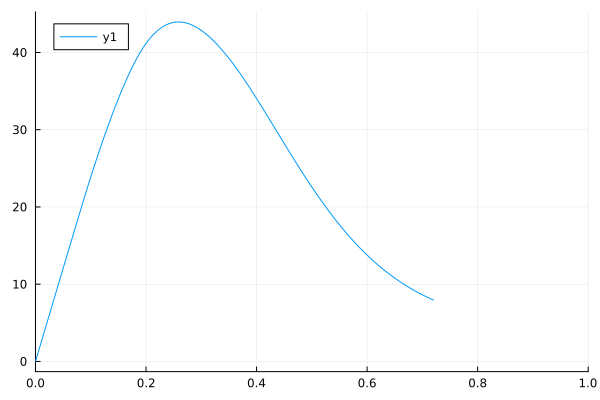

In [28]:
plot(Displacement,Load*0.4,legend=:topleft, xlimits = (0,1.0))

In [29]:
using DelimitedFiles
Disp = writedlm("PdeltaDataWedgeSplit_FeynKrackhabp1.csv",  [Displacement Load], ',')

In [ ]:
0.3/1e-4